In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
df = pd.read_csv(r"C:\Users\ainis\Downloads\archive (8)\BAJAJ-AUTO.csv")
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJ-AUTO,EQ,2101.05,898.00,898.0,551.35,600.25,604.75,624.61,3972485,2.481245e+14,NaN,1202933,0.3028
1,2008-05-27,BAJAJ-AUTO,EQ,604.75,624.70,639.0,580.30,595.50,593.15,606.43,1751063,1.061901e+14,NaN,369389,0.2110
2,2008-05-28,BAJAJ-AUTO,EQ,593.15,561.65,621.9,561.65,605.10,608.15,608.75,1652355,1.005877e+14,NaN,898602,0.5438
3,2008-05-29,BAJAJ-AUTO,EQ,608.15,619.40,619.4,576.00,600.00,599.45,600.98,669269,4.022165e+13,NaN,449951,0.6723
4,2008-05-30,BAJAJ-AUTO,EQ,599.45,605.40,607.0,538.00,576.25,571.70,565.55,1262117,7.137937e+13,NaN,936432,0.7420


In [3]:
print(df.isnull().sum())

Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                746
Deliverable Volume      0
%Deliverble             0
dtype: int64


In [4]:
df.dropna(inplace=True)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df = df.sort_values('Date')

In [8]:
df.reset_index(drop=True, inplace=True)

In [9]:
features = ['Prev Close','Open','High','Low','Last',
            'Close','VWAP','Volume','Turnover',
            'Trades','Deliverable Volume']

data = df[features]
data.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,1344.5,1346.2,1364.9,1325.00,1330.00,1335.60,1343.36,577275,7.754886e+13,19239.0,357565
1,1335.6,1325.0,1374.8,1310.60,1368.00,1368.50,1355.41,669185,9.070191e+13,31943.0,308672
2,1368.5,1375.0,1389.0,1367.15,1375.80,1375.80,1377.93,360138,4.962432e+13,47413.0,196713
3,1375.8,1360.0,1368.9,1338.00,1358.75,1361.70,1353.24,214882,2.907864e+13,12530.0,102078
4,1361.7,1360.0,1360.0,1339.40,1349.80,1350.05,1349.36,246553,3.326894e+13,10303.0,135761


In [10]:
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [11]:
input_days = 10
output_days = 5

X = []
Y = []

for i in range(len(scaled_data)-input_days-output_days):
    x = scaled_data[i:i+input_days]
    y = scaled_data[i+input_days:i+input_days+output_days]

    X.append(x)
    Y.append(y)

X = np.array(X)
Y = np.array(Y)

In [12]:
print(X.shape)
print(Y.shape)

(2441, 10, 11)
(2441, 5, 11)


In [13]:
train_size = int(len(X)*0.8)

X_train = X[:train_size]
Y_train = Y[:train_size]

X_test = X[train_size:]
Y_test = Y[train_size:]

In [14]:
X_train = torch.tensor(X_train,dtype=torch.float32)
Y_train = torch.tensor(Y_train,dtype=torch.float32)

X_test = torch.tensor(X_test,dtype=torch.float32)
Y_test = torch.tensor(Y_test,dtype=torch.float32)

In [15]:
class StockDataset(Dataset):
    def __init__(self,X,Y):
        self.X = X
        self.Y = Y

    def __len__(self):
        return len(self.X)

    def __getitem__(self,index):
        return self.X[index],self.Y[index]

In [16]:
train_dataset = StockDataset(X_train,Y_train)
test_dataset = StockDataset(X_test,Y_test)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=32,shuffle=False)

In [17]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,hidden_size,output_size):
        super(LSTMModel,self).__init__()

        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self,x):
        out,_ = self.lstm(x)

        out = out[:,-5:,:]

        out = self.fc(out)

        return out

In [18]:
input_size = 11
hidden_size = 64
output_size = 11

model = LSTMModel(input_size,hidden_size,output_size)

In [19]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [20]:
epochs = 50

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for x_batch,y_batch in train_loader:

        optimizer.zero_grad()

        output = model(x_batch)

        loss = criterion(output,y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 1.9983
Epoch 2, Loss: 0.1112
Epoch 3, Loss: 0.0678
Epoch 4, Loss: 0.0628
Epoch 5, Loss: 0.0620
Epoch 6, Loss: 0.0612
Epoch 7, Loss: 0.0594
Epoch 8, Loss: 0.0608
Epoch 9, Loss: 0.0589
Epoch 10, Loss: 0.0584
Epoch 11, Loss: 0.0580
Epoch 12, Loss: 0.0584
Epoch 13, Loss: 0.0577
Epoch 14, Loss: 0.0575
Epoch 15, Loss: 0.0571
Epoch 16, Loss: 0.0568
Epoch 17, Loss: 0.0575
Epoch 18, Loss: 0.0568
Epoch 19, Loss: 0.0560
Epoch 20, Loss: 0.0568
Epoch 21, Loss: 0.0564
Epoch 22, Loss: 0.0562
Epoch 23, Loss: 0.0562
Epoch 24, Loss: 0.0563
Epoch 25, Loss: 0.0559
Epoch 26, Loss: 0.0551
Epoch 27, Loss: 0.0564
Epoch 28, Loss: 0.0552
Epoch 29, Loss: 0.0551
Epoch 30, Loss: 0.0546
Epoch 31, Loss: 0.0552
Epoch 32, Loss: 0.0555
Epoch 33, Loss: 0.0546
Epoch 34, Loss: 0.0546
Epoch 35, Loss: 0.0559
Epoch 36, Loss: 0.0556
Epoch 37, Loss: 0.0541
Epoch 38, Loss: 0.0548
Epoch 39, Loss: 0.0547
Epoch 40, Loss: 0.0546
Epoch 41, Loss: 0.0540
Epoch 42, Loss: 0.0537
Epoch 43, Loss: 0.0532
Epoch 44, Loss: 0.05

In [21]:
model.eval()

predictions = []

with torch.no_grad():
    for x_batch,y_batch in test_loader:
        output = model(x_batch)
        predictions.append(output)

predictions = torch.cat(predictions)

In [22]:
predictions = predictions.numpy()
Y_test_np = Y_test.numpy()

In [23]:
pred_flat = predictions.reshape(-1,11)
true_flat = Y_test_np.reshape(-1,11)

In [24]:
mse = mean_squared_error(true_flat,pred_flat)
print("MSE:",mse)

MSE: 0.002926755929365754


In [25]:
rmse = np.sqrt(mse)
print("RMSE:",rmse)

RMSE: 0.054099500269094485


In [26]:
mae = mean_absolute_error(true_flat,pred_flat)
print("MAE:",mae)

MAE: 0.03402598574757576


In [27]:
pred_inverse = scaler.inverse_transform(pred_flat)
true_inverse = scaler.inverse_transform(true_flat)

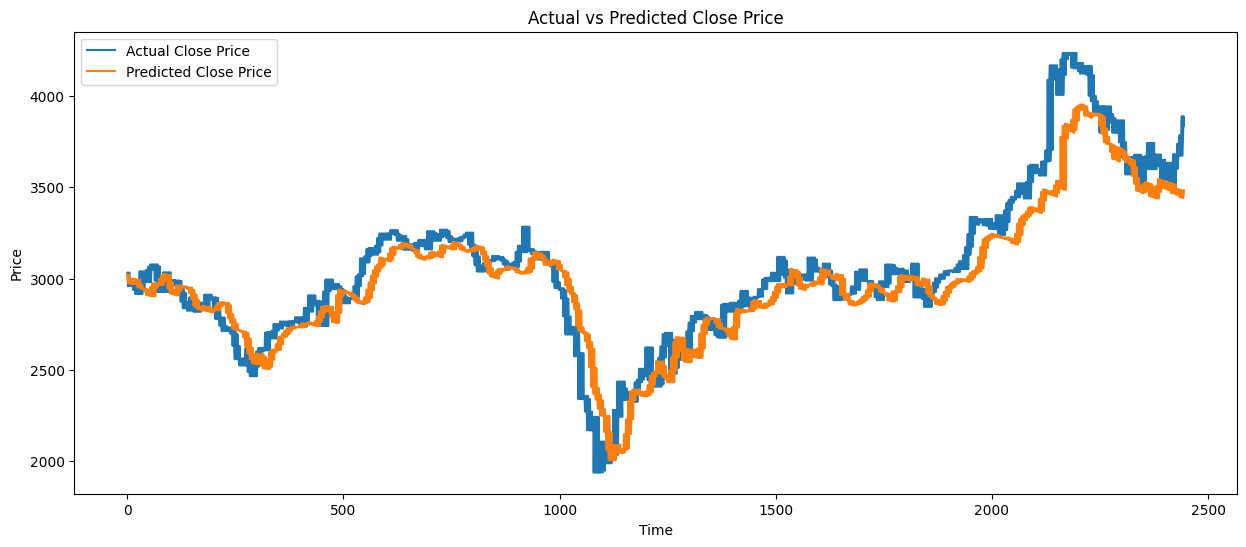

In [28]:
plt.figure(figsize=(15,6))

plt.plot(
    true_inverse[:,5],
    label='Actual Close Price'
)

plt.plot(
    pred_inverse[:,5],
    label='Predicted Close Price'
)

plt.legend()
plt.title("Actual vs Predicted Close Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()

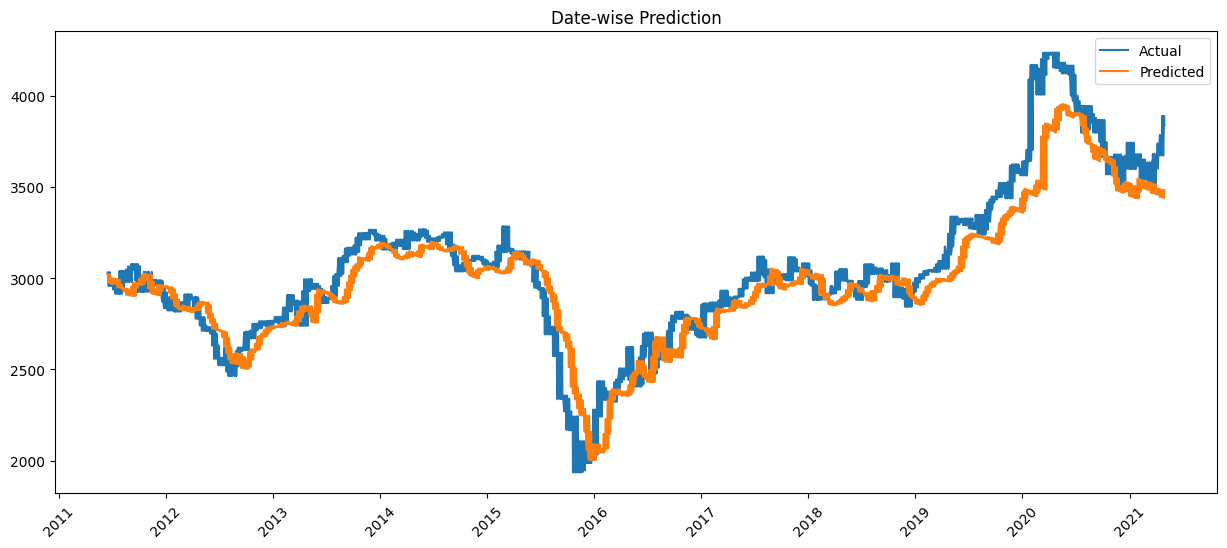

In [29]:
dates = df['Date'][-len(true_inverse):]

plt.figure(figsize=(15,6))

plt.plot(
    dates,
    true_inverse[:,5],
    label='Actual'
)

plt.plot(
    dates,
    pred_inverse[:,5],
    label='Predicted'
)

plt.legend()

plt.xticks(rotation=45)

plt.title("Date-wise Prediction")

plt.show()